# Donor Churn Analysis Pipeline

## 1. Problem Framing

**Business Question:** Which supporters are at high risk of churning so the fundraising team can run re-engagement outreach earlier?

**Who cares:** Development / fundraising staff and leadership need a ranked list and clear rationale so limited outreach time goes to supporters most likely to disengage.

**Predictive vs explanatory (textbook framing):** This pipeline uses **both** lenses. A **predictive** model (Random Forest) answers *who* to contact first for out-of-sample ranking and thresholds. An **explanatory** model (Logistic Regression) answers *what patterns* are associated with churn risk (coefficients / odds ratios) for staff trust and discussion—without claiming causation from observational data.

**Candidate churn definitions:**
- 90-day churn: no donation activity in the next 90 days
- 180-day churn: no donation activity in the next 180 days

We compare both definitions and choose the one that is most useful for operations and model quality.

**Leakage rule:** all features come from data available at prediction time only.

## Predictive and Explanatory Modeling Map

This notebook intentionally includes **both** modeling lenses:

- **Predictive modeling** (for operational ranking/action):
  - Random Forest classifier training and metric comparison in `## 3. Modeling & Feature Selection` and `## 4. Evaluation & Interpretation`
  - Threshold tuning/action tiers used for campaign decisions

- **Explanatory modeling** (for interpretation of relationships):
  - Logistic Regression model in `## 3. Modeling & Feature Selection`
  - Odds-ratio interpretation in `## 5. Causal and Relationship Analysis`

In short: **Random Forest = predictive decision support**, **Logistic Regression = explanatory interpretation**.

## 2. Data Acquisition, Preparation & Exploration

Core files:
- `supporters.csv`
- `donations.csv`

Feature design includes recency, frequency, value, trend, channel/campaign behavior, and supporter profile fields such as `acquisition_channel`.

In [1]:
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    def display(x):
        if hasattr(x, "to_string"):
            print(x.to_string(index=False))
        else:
            print(x)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, average_precision_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_cwd = Path.cwd()
if (_cwd / "data").is_dir():
    DATA_DIR = _cwd / "data"
elif (_cwd.parent / "data").is_dir():
    DATA_DIR = _cwd.parent / "data"
else:
    raise FileNotFoundError("Could not find data/. Expected ./data or ../data.")

print("Using DATA_DIR:", DATA_DIR)

Using DATA_DIR: g:\My Drive\Winter 2026\IS 455 - Machine Learning (MK)\INTEX\data


Supporters: (60, 15)
Donations: (420, 13)

Date range: 2023-01-09 to 2026-03-01

Donation types:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

Missing values (supporters, top columns):
organization_name      56
first_name              4
last_name               4
first_donation_date     1
display_name            0
supporter_id            0
supporter_type          0
relationship_type       0
dtype: int64

Missing values (donations, top columns):
referral_post_id    343
campaign_name       275
amount              186
currency_code       186
donation_id           0
is_recurring          0
donation_date         0
donation_type         0
dtype: int64


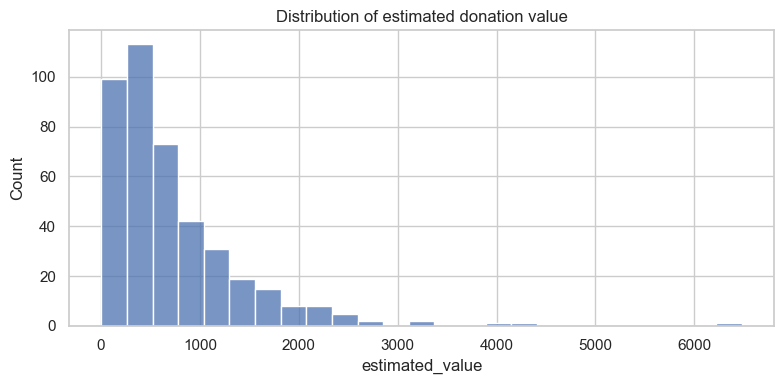

In [2]:
supporters = pd.read_csv(DATA_DIR / "supporters.csv").drop_duplicates(subset=["supporter_id"])
donations = pd.read_csv(DATA_DIR / "donations.csv")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")
donations = donations.dropna(subset=["supporter_id", "donation_date"]).copy()

print("Supporters:", supporters.shape)
print("Donations:", donations.shape)
print()
print("Date range:", donations["donation_date"].min().date(), "to", donations["donation_date"].max().date())
print()
print("Donation types:")
print(donations["donation_type"].value_counts())

# Compact EDA checks for rubric coverage
print()
print("Missing values (supporters, top columns):")
print(supporters.isna().sum().sort_values(ascending=False).head(8))
print()
print("Missing values (donations, top columns):")
print(donations.isna().sum().sort_values(ascending=False).head(8))

if sns is not None:
    plt.figure(figsize=(8, 4))
    sns.histplot(donations["estimated_value"].dropna(), bins=25)
    plt.title("Distribution of estimated donation value")
    plt.xlabel("estimated_value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [3]:
def build_panel(don_df, sup_df):
    monthly = (
        don_df.assign(month=don_df["donation_date"].dt.to_period("M").dt.to_timestamp())
        .groupby(["supporter_id", "month"], as_index=False)
        .agg(
            donation_events=("donation_id", "count"),
            est_value_sum=("estimated_value", "sum"),
            n_campaign_events=("campaign_name", lambda s: s.notna().sum()),
        )
    )
    monthly["est_value_sum"] = monthly["est_value_sum"].fillna(0)

    month_idx = pd.date_range(monthly["month"].min(), monthly["month"].max(), freq="MS")
    base = pd.MultiIndex.from_product([sup_df["supporter_id"].unique(), month_idx], names=["supporter_id", "month"]).to_frame(index=False)

    panel = base.merge(monthly, on=["supporter_id", "month"], how="left")
    panel[["donation_events", "est_value_sum", "n_campaign_events"]] = panel[["donation_events", "est_value_sum", "n_campaign_events"]].fillna(0)
    panel = panel.sort_values(["supporter_id", "month"]).reset_index(drop=True)

    panel = panel.merge(
        sup_df[["supporter_id", "acquisition_channel", "relationship_type", "region", "country", "supporter_type"]],
        on="supporter_id",
        how="left",
    )

    # Calendar seasonality context at prediction month
    panel["month_of_year"] = panel["month"].dt.month.astype(int)
    panel["quarter_of_year"] = panel["month"].dt.quarter.astype(int)

    # Donor-level seasonality concentration (higher = donations clustered in fewer months)
    month_counts = (
        don_df.assign(month_of_year=don_df["donation_date"].dt.month)
        .groupby(["supporter_id", "month_of_year"])
        .size()
        .rename("month_event_count")
        .reset_index()
    )
    seasonality = month_counts.groupby("supporter_id")["month_event_count"].agg(total_events="sum", peak_month_events="max").reset_index()
    seasonality["active_month_concentration"] = (seasonality["peak_month_events"] / seasonality["total_events"]).fillna(0)
    seasonality["seasonal_supporter_flag"] = (seasonality["active_month_concentration"] >= 0.50).astype(int)
    panel = panel.merge(seasonality[["supporter_id", "active_month_concentration", "seasonal_supporter_flag"]], on="supporter_id", how="left")
    panel[["active_month_concentration", "seasonal_supporter_flag"]] = panel[["active_month_concentration", "seasonal_supporter_flag"]].fillna(0)

    g = panel.groupby("supporter_id", group_keys=False)
    last_month = panel["month"].where(panel["donation_events"] > 0).groupby(panel["supporter_id"]).ffill()
    panel["days_since_last_donation"] = (panel["month"] - last_month).dt.days.fillna(9999)

    prev_year = panel[["supporter_id", "month", "donation_events"]].copy()
    prev_year["month"] = prev_year["month"] + pd.DateOffset(years=1)
    prev_year = prev_year.rename(columns={"donation_events": "events_same_month_last_year"})
    panel = panel.merge(prev_year, on=["supporter_id", "month"], how="left")
    panel["events_same_month_last_year"] = panel["events_same_month_last_year"].fillna(0)
    panel["gave_same_month_last_year"] = (panel["events_same_month_last_year"] > 0).astype(int)

    for w in [3, 6, 12]:
        panel[f"events_{w}m"] = g["donation_events"].shift(1).rolling(w, min_periods=1).sum().reset_index(level=0, drop=True).fillna(0)
        panel[f"value_{w}m"] = g["est_value_sum"].shift(1).rolling(w, min_periods=1).sum().reset_index(level=0, drop=True).fillna(0)
        panel[f"campaign_events_{w}m"] = g["n_campaign_events"].shift(1).rolling(w, min_periods=1).sum().reset_index(level=0, drop=True).fillna(0)

    g2 = panel.groupby("supporter_id", group_keys=False)
    panel["events_trend_3m_vs_prev3m"] = panel["events_3m"] - g2["events_3m"].shift(3).fillna(0)
    panel["value_trend_3m_vs_prev3m"] = panel["value_3m"] - g2["value_3m"].shift(3).fillna(0)
    return panel


def add_label(panel_df, don_df, horizon_days):
    donor_dates = don_df.groupby("supporter_id")["donation_date"].apply(list).to_dict()
    out = panel_df.copy()

    def f(row):
        sid = row["supporter_id"]
        t0 = row["month"]
        t1 = t0 + pd.Timedelta(days=horizon_days)
        return int(not any((d > t0) and (d <= t1) for d in donor_dates.get(sid, [])))

    out[f"churn_{horizon_days}d"] = out.apply(f, axis=1)
    return out


panel = build_panel(donations, supporters)
panel = add_label(panel, donations, 90)
panel = add_label(panel, donations, 180)
panel = panel[panel["month"] >= (panel["month"].min() + pd.offsets.MonthBegin(3))]
panel = panel[panel["month"] <= (panel["month"].max() - pd.offsets.MonthBegin(1))]

display(panel[["supporter_id", "month", "events_3m", "value_3m", "churn_90d", "churn_180d"]].head())

,supporter_id,month,events_3m,value_3m,churn_90d,churn_180d
3,1,2023-04-01,1.0,774.61,0,0
4,1,2023-05-01,1.0,774.61,0,0
5,1,2023-06-01,1.0,774.61,0,0
6,1,2023-07-01,1.0,606.91,0,0
7,1,2023-08-01,4.0,1590.05,1,0


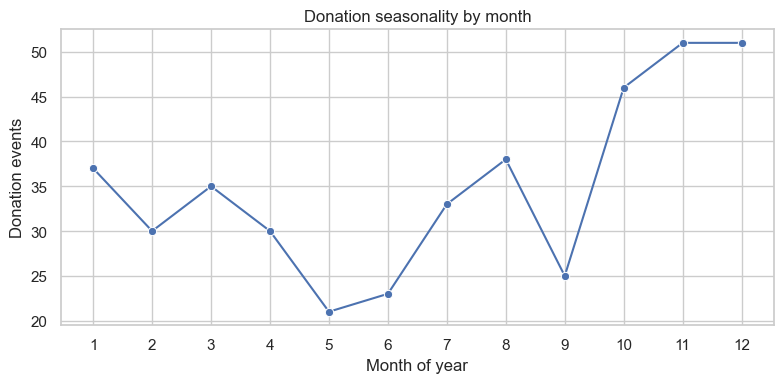

Share of supporters flagged as seasonal-pattern donors: 25.0%


In [4]:
# Seasonality diagnostic: when do donations tend to happen?
month_profile = (
    donations.assign(month_of_year=donations["donation_date"].dt.month)
    .groupby("month_of_year")
    .size()
    .rename("donation_events")
    .reset_index()
)

plt.figure(figsize=(8, 4))
if sns is not None:
    sns.lineplot(data=month_profile, x="month_of_year", y="donation_events", marker="o")
else:
    plt.plot(month_profile["month_of_year"], month_profile["donation_events"], marker="o")
plt.title("Donation seasonality by month")
plt.xlabel("Month of year")
plt.ylabel("Donation events")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

seasonal_rate = panel[["supporter_id", "seasonal_supporter_flag"]].drop_duplicates()["seasonal_supporter_flag"].mean()
print(f"Share of supporters flagged as seasonal-pattern donors: {seasonal_rate:.1%}")

### Feature Glossary (Generated Fields)

To keep field names clear, here are plain-language definitions for engineered features:

- `days_since_last_donation`: days since this supporter last had any donation activity (as of month `t`).
- `events_3m`, `events_6m`, `events_12m`: number of donation events in the prior 3/6/12 months (lookback only, excluding current month).
- `value_3m`, `value_6m`, `value_12m`: total `estimated_value` of donations in the prior 3/6/12 months.
- `campaign_events_3m`, `campaign_events_6m`, `campaign_events_12m`: number of donations tied to a named campaign in the prior 3/6/12 months.
- `events_trend_3m_vs_prev3m`: change in event count between the most recent 3-month window and the previous 3-month window.
- `value_trend_3m_vs_prev3m`: change in estimated donation value between the most recent 3-month window and the previous 3-month window.
- `month_of_year`: calendar month number (1-12) for the prediction snapshot.
- `quarter_of_year`: calendar quarter number (1-4) for the prediction snapshot.
- `events_same_month_last_year`: donation-event count in the same calendar month one year earlier.
- `gave_same_month_last_year`: flag (1/0) showing whether supporter gave in the same month last year.
- `active_month_concentration`: share of a supporter's lifetime donation events that occurred in their single highest-activity month (higher means more seasonal concentration).
- `seasonal_supporter_flag`: flag (1/0) for concentrated seasonal donors (`active_month_concentration >= 0.50`).
- `churn_90d`, `churn_180d`: label flag where 1 means no donation activity in the next 90 or 180 days, respectively.

All generated fields are built from information available at prediction time to avoid leakage.

## 3. Modeling & Feature Selection

- Explanatory model: Logistic Regression (`class_weight='balanced'`)
- Predictive model: Random Forest (`class_weight='balanced'`)
- Shared preprocessing: `ColumnTransformer` + `Pipeline`
- Split strategy: chronological holdout (no random shuffle)

In [5]:
feature_cols = [
    "days_since_last_donation",
    "events_3m", "events_6m", "events_12m",
    "value_3m", "value_6m", "value_12m",
    "campaign_events_3m", "campaign_events_6m", "campaign_events_12m",
    "events_trend_3m_vs_prev3m", "value_trend_3m_vs_prev3m",
    "month_of_year", "quarter_of_year",
    "events_same_month_last_year", "gave_same_month_last_year",
    "active_month_concentration", "seasonal_supporter_flag",
    "acquisition_channel", "relationship_type", "region", "country", "supporter_type",
]
cat_cols = ["acquisition_channel", "relationship_type", "region", "country", "supporter_type", "month_of_year", "quarter_of_year", "seasonal_supporter_flag", "gave_same_month_last_year"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ]
)

def chrono_split(df, target):
    mdf = df[["supporter_id", "month", target] + feature_cols].dropna().copy()
    cutoff = mdf["month"].quantile(0.8)
    tr = mdf[mdf["month"] <= cutoff]
    te = mdf[mdf["month"] > cutoff]
    return tr, te, tr[feature_cols], tr[target].astype(int), te[feature_cols], te[target].astype(int)

def fit_pair(X, y):
    logit = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))])
    rf = Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=350, max_depth=10, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1))])
    logit.fit(X, y)
    rf.fit(X, y)
    return logit, rf

def score(model, X, y, th=0.5):
    p = model.predict_proba(X)[:, 1]
    yhat = (p >= th).astype(int)
    return {
        "accuracy": accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat, zero_division=0),
        "f1": f1_score(y, yhat, zero_division=0),
        "roc_auc": roc_auc_score(y, p),
        "pr_auc": average_precision_score(y, p),
        "cm": confusion_matrix(y, yhat).tolist(),
        "proba": p,
    }

## 4. Evaluation & Interpretation

This section compares models and churn horizons using chronological holdout metrics, then interprets the results in business terms.

Validation approach:
- We use a **chronological holdout** (no random shuffle) to mimic real forecasting and avoid timeline leakage.
- This is a deliberate alternative to random cross-validation because future records must not inform past predictions.

Real-world error consequences in fundraising:
- **False positive:** supporter is flagged as high-risk but would have stayed active anyway (extra outreach cost/time).
- **False negative:** supporter is not flagged but actually churns (missed retention opportunity and possible donation loss).

,horizon,model,positive_rate_test,pr_auc,roc_auc,recall,precision,f1,accuracy
0,churn_180d,Logistic,0.545238,0.622741,0.577722,0.445415,0.633540,0.523077,0.557143
1,churn_180d,RandomForest,0.545238,0.745913,0.752418,0.493450,0.733766,0.590078,0.626190
2,churn_90d,Logistic,0.616667,0.703962,0.592244,0.424710,0.723684,0.535280,0.545238
3,churn_90d,RandomForest,0.616667,0.803712,0.773112,0.756757,0.771654,0.764133,0.711905


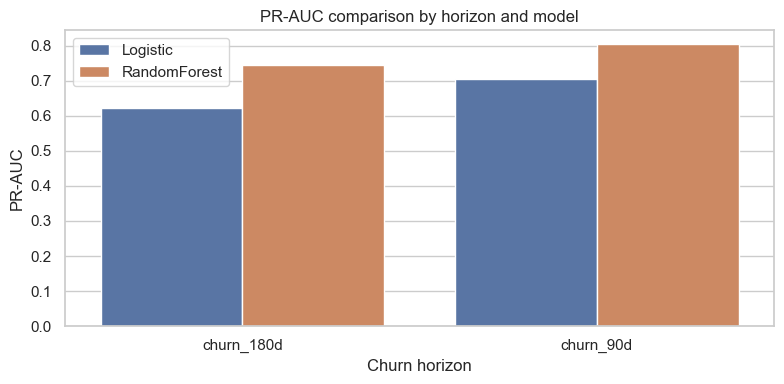

,chosen_horizon,chosen_model,selection_basis
0,churn_90d,RandomForest,highest PR-AUC on chronological holdout


In [6]:
rows = []
store = {}

for target in ["churn_90d", "churn_180d"]:
    tr, te, Xtr, ytr, Xte, yte = chrono_split(panel, target)
    logit, rf = fit_pair(Xtr, ytr)
    s_log = score(logit, Xte, yte)
    s_rf = score(rf, Xte, yte)
    rows.append({"horizon": target, "model": "Logistic", "positive_rate_test": yte.mean(), **{k: s_log[k] for k in ["pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]}})
    rows.append({"horizon": target, "model": "RandomForest", "positive_rate_test": yte.mean(), **{k: s_rf[k] for k in ["pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]}})
    store[target] = {"tr": tr, "te": te, "Xtr": Xtr, "ytr": ytr, "Xte": Xte, "yte": yte, "logit": logit, "rf": rf, "s_log": s_log, "s_rf": s_rf}

results = pd.DataFrame(rows)
results_sorted = results.sort_values(["horizon", "model"]).reset_index(drop=True)
display(results_sorted)

# Chart 1: model comparison by PR-AUC
plot_df = results_sorted.copy()
plt.figure(figsize=(8, 4))
if sns is not None:
    sns.barplot(data=plot_df, x="horizon", y="pr_auc", hue="model")
else:
    for i, m in enumerate(plot_df["model"].unique()):
        sub = plot_df[plot_df["model"] == m]
        plt.bar(np.arange(len(sub)) + i * 0.35, sub["pr_auc"], width=0.35, label=m)
        plt.xticks(np.arange(len(sub)) + 0.17, sub["horizon"].tolist())
plt.title("PR-AUC comparison by horizon and model")
plt.ylabel("PR-AUC")
plt.xlabel("Churn horizon")
plt.legend()
plt.tight_layout()
plt.show()

best = results.sort_values("pr_auc", ascending=False).iloc[0]
chosen_horizon = best["horizon"]
chosen_model = best["model"]
selection_summary = pd.DataFrame([
    {
        "chosen_horizon": chosen_horizon,
        "chosen_model": chosen_model,
        "selection_basis": "highest PR-AUC on chronological holdout",
    }
])
display(selection_summary)

,threshold,precision,recall,f1,flagged_supporters
0,0.20,0.712707,0.996139,0.830918,362
1,0.25,0.730878,0.996139,0.843137,353
2,0.30,0.739884,0.988417,0.846281,346
3,0.35,0.758308,0.969112,0.850847,331
4,0.40,0.765273,0.918919,0.835088,311
5,0.45,0.768683,0.833977,0.800000,281
6,0.50,0.771654,0.756757,0.764133,254
7,0.55,0.781553,0.621622,0.692473,206
8,0.60,0.802548,0.486486,0.605769,157
9,0.65,0.823009,0.359073,0.500000,113


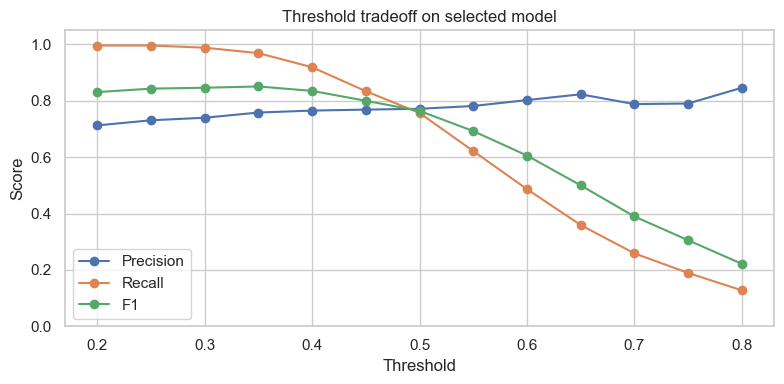

,recommended_threshold,note
0,0.5,Lower threshold increases recall; higher thres...


In [7]:
chosen = store[chosen_horizon]
best_model = chosen["rf"] if chosen_model == "RandomForest" else chosen["logit"]
Xte, yte = chosen["Xte"], chosen["yte"]

p = best_model.predict_proba(Xte)[:, 1]
th_rows = []
for th in np.arange(0.20, 0.81, 0.05):
    yhat = (p >= th).astype(int)
    th_rows.append({"threshold": float(th), "precision": precision_score(yte, yhat, zero_division=0), "recall": recall_score(yte, yhat, zero_division=0), "f1": f1_score(yte, yhat, zero_division=0), "flagged_supporters": int(yhat.sum())})

th_df = pd.DataFrame(th_rows)
display(th_df)

# Chart 2: threshold tradeoff (precision vs recall)
plt.figure(figsize=(8, 4))
plt.plot(th_df["threshold"], th_df["precision"], marker="o", label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], marker="o", label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], marker="o", label="F1")
plt.title("Threshold tradeoff on selected model")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()
eligible = th_df[th_df["recall"] >= 0.70]
rec_th = eligible.sort_values("precision", ascending=False).iloc[0]["threshold"] if len(eligible) else th_df.sort_values("f1", ascending=False).iloc[0]["threshold"]
threshold_recommendation = pd.DataFrame([
    {
        "recommended_threshold": float(rec_th),
        "note": "Lower threshold increases recall; higher threshold reduces outreach volume",
    }
])
display(threshold_recommendation)

In [8]:
## Explanatory model output (odds ratios)
logit = chosen["logit"]
feat_names = logit.named_steps["prep"].get_feature_names_out()
coef = logit.named_steps["model"].coef_[0]
or_df = pd.DataFrame({"feature": feat_names, "coef": coef, "odds_ratio": np.exp(coef), "abs_coef": np.abs(coef)}).sort_values("abs_coef", ascending=False)
display(or_df[["feature", "coef", "odds_ratio"]].head(20))
print("Plain language: odds_ratio > 1 means higher predicted churn odds, < 1 means lower predicted churn odds. This is association, not causation.")

,feature,coef,odds_ratio
26,cat__country_Canada,-1.418780,0.242009
29,cat__country_USA,1.357719,3.887318
35,cat__supporter_type_Volunteer,0.754765,2.127111
13,num__active_month_concentration,0.587651,1.799756
19,cat__acquisition_channel_WordOfMouth,0.479114,1.614643
25,cat__region_Visayas,-0.426973,0.652481
51,cat__quarter_of_year_4,-0.419561,0.657335
23,cat__region_Luzon,0.401402,1.493918
18,cat__acquisition_channel_Website,0.391685,1.479471
33,cat__supporter_type_SkillsContributor,-0.387389,0.678827


Plain language: odds_ratio > 1 means higher predicted churn odds, < 1 means lower predicted churn odds. This is association, not causation.


In [9]:
## Sensitivity check: monetary-only churn labels
money = donations[donations["donation_type"] == "Monetary"].copy()
money_panel = build_panel(money, supporters)
money_panel = add_label(money_panel, money, 180)
money_panel = money_panel[money_panel["month"] >= (money_panel["month"].min() + pd.offsets.MonthBegin(3))]
money_panel = money_panel[money_panel["month"] <= (money_panel["month"].max() - pd.offsets.MonthBegin(1))]

mtr, mte, mXtr, mytr, mXte, myte = chrono_split(money_panel, "churn_180d")
m_log, m_rf = fit_pair(mXtr, mytr)
m_sc = score(m_rf, mXte, myte)

compare = pd.DataFrame([
    {"label_scope": "any donation (chosen pipeline)", "horizon": chosen_horizon, "rf_pr_auc": chosen["s_rf"]["pr_auc"], "rf_roc_auc": chosen["s_rf"]["roc_auc"]},
    {"label_scope": "monetary only (sensitivity)", "horizon": "churn_180d", "rf_pr_auc": m_sc["pr_auc"], "rf_roc_auc": m_sc["roc_auc"]},
])
display(compare)
print("If this sensitivity test shows a meaningful performance difference, choose the churn label definition that best matches the fundraising objective (overall supporter re-engagement vs monetary-gift retention).")

,label_scope,horizon,rf_pr_auc,rf_roc_auc
0,any donation (chosen pipeline),churn_90d,0.803712,0.773112
1,monetary only (sensitivity),churn_180d,0.890045,0.809639


If this sensitivity test shows a meaningful performance difference, choose the churn label definition that best matches the fundraising objective (overall supporter re-engagement vs monetary-gift retention).


## 5. Causal and Relationship Analysis

This section explains what relationships the model found, and what we can and cannot claim.

**What we found:**
- Recency/frequency/value patterns and selected supporter profile variables are associated with churn risk.
- The explanatory logistic model gives direction and rough magnitude (odds ratios).
- The predictive random forest captures non-linear patterns that may improve ranking quality.

**Causal caution:**
- These are observational data patterns, not proof of cause-and-effect.
- We can say features are associated with churn risk, but not that they directly cause churn.

**Operational threshold guidance (from Section 4 output):**
- **High risk:** probability >= threshold
- **Medium risk:** probability within 0.10 below threshold
- **Low risk:** below medium band

Operations suggestion:
- Prioritize high-risk supporters for personalized follow-up.
- Use medium-risk list for lighter-touch campaigns.
- Re-score monthly and re-tune threshold based on team outreach capacity.

## 6. Deployment Notes (Safe Harbor — live integration)

**Architecture:** Shared feature code in `ml_service/`; inference in `ml_api/` (FastAPI); .NET `backend/backend/Controllers/MlController.cs` proxies requests using `Ml:BaseUrl` and optional `Ml:ApiKey` (header `X-ML-API-Key`).

**Health / audit:** GET /api/Ml/deployment-status and staff page /admin/ml-integration.

**Docs & env:** See docs/ml-deployment.md and docs/SETUP.md (ML section).

**Retrain from CSVs:** Use scripts/train_*.py where present; notebooks stay executable against repo data/.

**This pipeline (donor churn):** Predictive model artifact models/donor_churn_rf.joblib. Train: python scripts/train_donor_churn.py. FastAPI: POST /predict/donor-churn. .NET: GET /api/Ml/donor-churn-scores. **UI:** /donors — panel *Live ML — donor churn*.


### Donor Action Playbook

Use model scores to drive monthly outreach decisions. This table maps churn risk to a concrete action plan for a small fundraising team.


In [10]:
# Action playbook table for deployment
thr = float(rec_th) if 'rec_th' in globals() else 0.50

donor_playbook = pd.DataFrame([
    {
        "Risk tier": "High",
        "Score rule": f"probability >= {thr:.2f}",
        "Team action": "Personalized outreach within 7 days (thank-you + specific impact update + tailored ask).",
        "Channel": "Email + direct message/call",
        "KPI (30-90d)": "re-donation rate"
    },
    {
        "Risk tier": "Medium",
        "Score rule": f"{max(0.0, thr-0.10):.2f} <= probability < {thr:.2f}",
        "Team action": "Light-touch nurture sequence (impact story + campaign reminder).",
        "Channel": "Email sequence",
        "KPI (30-90d)": "re-engagement click + donation conversion"
    },
    {
        "Risk tier": "Low",
        "Score rule": f"probability < {max(0.0, thr-0.10):.2f}",
        "Team action": "Stewardship only; no urgent intervention.",
        "Channel": "Newsletter/social",
        "KPI (30-90d)": "retention stability"
    },
])

print("DONOR RE-ENGAGEMENT PLAYBOOK")
print(donor_playbook.to_string(index=False, col_space=18))

capacity_note = pd.DataFrame([
    {
        "Recommended monthly operating rule": "Set threshold so High-risk queue matches outreach capacity.",
        "Review cadence": "Monthly re-score + quarterly threshold review",
        "Primary decision metric": "PR-AUC + high-tier re-donation rate"
    }
])
print("\nOPERATING RULE")
print(capacity_note.to_string(index=False, col_space=18))

DONOR RE-ENGAGEMENT PLAYBOOK
         Risk tier                 Score rule                                                                              Team action                     Channel                              KPI (30-90d)
              High        probability >= 0.50 Personalized outreach within 7 days (thank-you + specific impact update + tailored ask). Email + direct message/call                          re-donation rate
            Medium 0.40 <= probability < 0.50                         Light-touch nurture sequence (impact story + campaign reminder).              Email sequence re-engagement click + donation conversion
               Low         probability < 0.40                                                Stewardship only; no urgent intervention.           Newsletter/social                       retention stability

OPERATING RULE
                         Recommended monthly operating rule                                Review cadence             Primary decision 